     导师  当前人数
12   石田    11
13   周欣     9
14  代瑞慧     9
15  李继文     9
16  刘红蕾     6
17  赵丽丽     5
18  张力红     5
19  周晓斐     4
20   高贵     4
21  纪晓婧     2
22  付美臻     2
23   李现     1


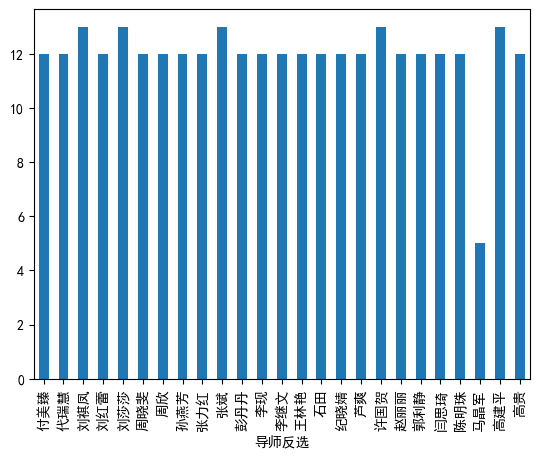

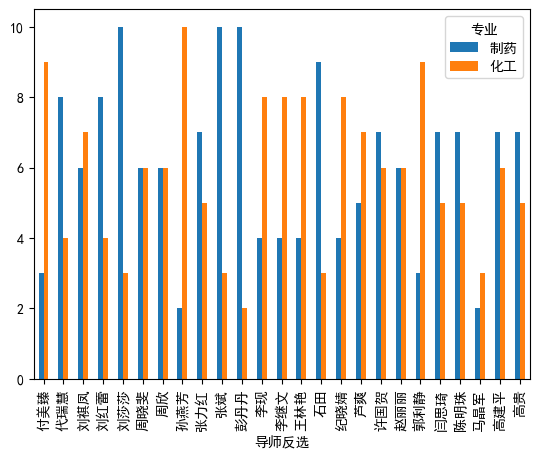

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
# 用来正常显示中文标签
plt.rcParams['font.sans-serif'] = ['SimHei']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('2024级化工与制药类导师预选表.xlsx')
# 如果专业班级列包含制药，则将制药添加到专业列，如果专业班级列包含化工，则将化工添加到专业列
df['专业'] = df['专业班级'].apply(lambda x: '制药' if '制药' in x else '化工' if '化学' in x else x)
# 统计第一志愿每个导师的个数，如果个数小于12，则将导师名称添加到导师反选列中
df['第一志愿'].value_counts()[df['第一志愿'].value_counts() < 12].index
df.loc[df['第一志愿'].isin(df['第一志愿'].value_counts()[df['第一志愿'].value_counts() < 12].index), '导师反选'] = df['第一志愿']
# 如果第二志愿列的导师名称不在导师反选列中，且对应导师反选列为NaN，则将导师名称添加到导师反选列中，否则导师反选保持原始数据
df.loc[(~df['第二志愿'].isin(df['导师反选'])) & (pd.isna(df['导师反选'])), '导师反选'] = df['第二志愿']
df.loc[(~df['第三志愿'].isin(df['导师反选'])) & (pd.isna(df['导师反选'])), '导师反选'] = df['第三志愿']

# 统计导师反选列每个导师的个数，如果个数小于12，则从第二志愿中选择导师名称添加到导师反选列中，直到个数不多于12
# 初始化导师计数器
all_mentors = list(df['导师反选'].value_counts()[df['导师反选'].value_counts() < 12].index)
all_mentors.remove('马晶军')
mentor_counts = {mentor: 0 for mentor in all_mentors}
current_counts = df['导师反选'].value_counts().to_dict()
for mentor, count in current_counts.items():
    mentor_counts[mentor] = count
# 按导师名称排序处理
for mentor in sorted(all_mentors):
    current_count = mentor_counts.get(mentor, 0)
    if current_count >= 12:
        continue
    needed = 12 - current_count
    if needed <= 0:
        continue

    # 找到符合条件的候选学生：导师反选为空且第二志愿是该导师
    candidates = df[(df['导师反选'].isna()) & (df['第二志愿'] == mentor)]
    num_to_fill = min(needed, len(candidates))

    if num_to_fill > 0:
        selected_indices = candidates.index[:num_to_fill]
        df.loc[selected_indices, '导师反选'] = mentor
        mentor_counts[mentor] += num_to_fill

# 统计导师反选列每个导师的个数，如果个数小于12，则从第三志愿中选择导师名称添加到导师反选列中，直到个数不多于12
# 初始化导师计数器
all_mentors = list(df['导师反选'].value_counts()[df['导师反选'].value_counts() < 12].index)
all_mentors.remove('马晶军')
mentor_counts = {mentor: 0 for mentor in all_mentors}
current_counts = df['导师反选'].value_counts().to_dict()
for mentor, count in current_counts.items():
    mentor_counts[mentor] = count
# 按导师名称排序处理
for mentor in sorted(all_mentors):
    current_count = mentor_counts.get(mentor, 0)
    if current_count >= 12:
        continue
    needed = 12 - current_count
    if needed <= 0:
        continue

    # 找到符合条件的候选学生：导师反选为空且第三志愿是该导师
    candidates = df[(df['导师反选'].isna()) & (df['第三志愿'] == mentor)]
    num_to_fill = min(needed, len(candidates))

    if num_to_fill > 0:
        selected_indices = candidates.index[:num_to_fill]
        df.loc[selected_indices, '导师反选'] = mentor
        mentor_counts[mentor] += num_to_fill

# 分配剩余学生
# 1. 初始化导师计数（排除马晶军）
current_counts = df[~df['导师反选'].isin(['马晶军'])]['导师反选'].value_counts().reset_index()
current_counts.columns = ['导师', '当前人数']
# 2. 筛选可分配导师（当前人数<12）并按人数降序排列
eligible_mentors = current_counts[current_counts['当前人数'] < 12] \
                    .sort_values(by='当前人数', ascending=False)
print(不足12个学生的导师：)
print(eligible_mentors)
# 3. 创建动态分配队列
mentor_queue = deque(eligible_mentors['导师'].tolist())
mentor_dict = eligible_mentors.set_index('导师')['当前人数'].to_dict()
# 4. 获取未分配学生
unassigned = df[df['导师反选'].isna()].index.tolist()
# 5. 执行分配
while unassigned and mentor_queue:
    current_mentor = mentor_queue.popleft()

    if mentor_dict[current_mentor] >= 12:
        continue

    # 分配一个学生
    student_idx = unassigned.pop(0)
    df.loc[student_idx, '导师反选'] = current_mentor
    mentor_dict[current_mentor] += 1

    # 重新入列（如果未满）
    if mentor_dict[current_mentor] < 12:
        mentor_queue.append(current_mentor)

# 按照导师反选分组，按照专业统计，统计每个导师每个专业的学生人数，并绘制柱状图
df.groupby('导师反选').size().plot(kind='bar')
df.groupby('导师反选')['专业'].value_counts().unstack().plot(kind='bar')
df.to_excel('导师分配表.xlsx')